# Running Power and Race Time Prediction

Jack Miller

April 5, 2023

In [1]:
from IPython.display import display, HTML
display(HTML("<style>.container { width:100% !important; }</style>"))

## Running Power Model

- A running power model is used to calculate the power required to run a pace on a given course

Most equations taken from:

- Van Dijk, H., & Van Megan, R. (2017). The Secret of Running. Meyer & Meyer Sport.

In [2]:
import matplotlib.pyplot as plt
import sys
import os
module_path = os.path.abspath(os.path.join('../source'))
if module_path not in sys.path:
    sys.path.append(module_path)
import numpy as np
import bonk
plotSize = (12,8)

athlete = bonk.Athlete()
environment = bonk.Environment()

## Personal Records

The model predicts my own personal records within ~1%

In [14]:
fivek = bonk.readCourse('5k.csv','5k')
tenk = bonk.readCourse('10k.csv','10k')
half = bonk.readCourse('21k.csv','half marathon')
full = bonk.readCourse('flatMarathon.csv','full marathon')
environment = bonk.Environment(temperature = 5, humidity = 0, wind = 0, altitude = 0, body = 1)
jack = bonk.Athlete(mass = 65, Ecor = 0.98, fatigueResistanceCoef = 0.07, Cd = 0.5, frontalArea = 0.5, vo2maxPower=5.1*65, glucoseConsumption = 60, startingGlycogen = 1500,temp=environment.temperature)

distances = [fivek, tenk, half, full]

for distance in distances:
    performance = bonk.Performance(environment,jack,distance)
    raceTime, power = performance.getRaceTime()
    h, m, s = bonk.getTime(raceTime)
    out = '{} race time: {:02d}:{:02d}:{:02d}'
    print(out.format(distance.name,int(h),int(m),int(s)))

5k race time: 00:17:34
10k race time: 00:36:31
half marathon race time: 01:20:55
full marathon race time: 02:49:53


## Backup

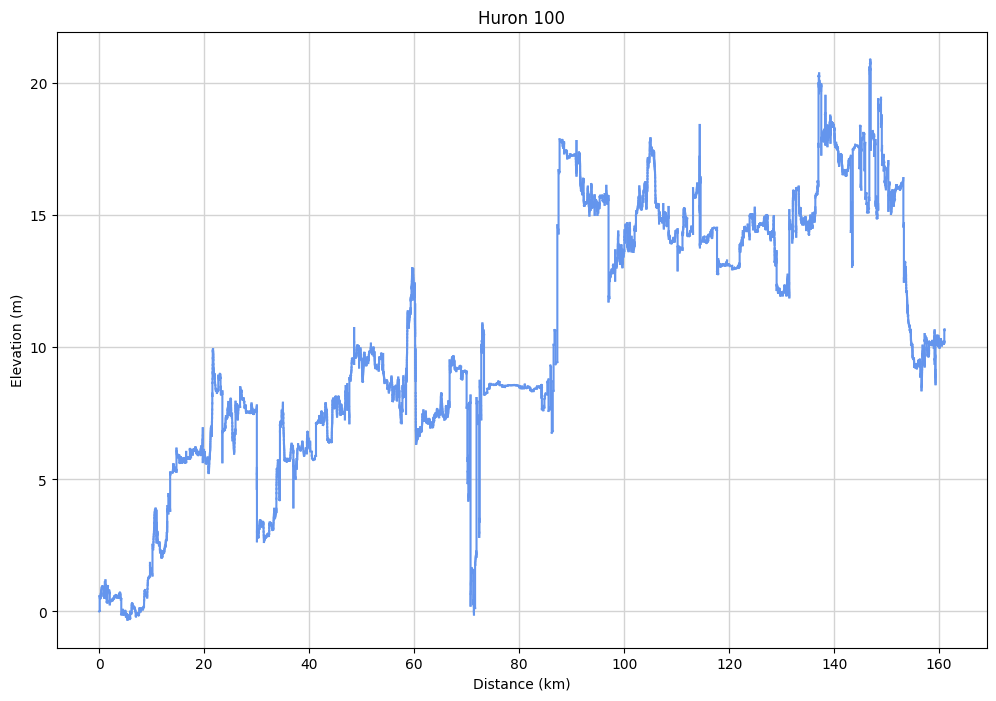

In [15]:
huron100Course = bonk.readCourse('Huron100.csv','Huron 100')

huron100Course.plotProfile()

### Even Power

Race time: 14:07:31
Mile: 01 - 08:17
Mile: 02 - 08:11
Mile: 03 - 08:12
Mile: 04 - 08:12
Mile: 05 - 08:11
Mile: 06 - 08:13
Mile: 07 - 08:20
Mile: 08 - 08:12
Mile: 09 - 08:23
Mile: 10 - 08:15
Mile: 11 - 08:13
Mile: 12 - 08:11
Mile: 13 - 08:17
Mile: 14 - 08:16
Mile: 15 - 08:42
Mile: 16 - 08:10
Mile: 17 - 08:22
Mile: 18 - 08:11
Mile: 19 - 09:02
Mile: 20 - 08:11
Mile: 21 - 08:14
Mile: 22 - 08:25
Mile: 23 - 08:29
Mile: 24 - 08:14
Mile: 25 - 08:11
Mile: 26 - 08:18
Mile: 27 - 08:11
Mile: 28 - 08:13
Mile: 29 - 08:11
Mile: 30 - 08:26
Mile: 31 - 08:19
Mile: 32 - 08:12
Mile: 33 - 08:11
Mile: 34 - 08:12
Mile: 35 - 08:11
Mile: 36 - 08:17
Mile: 37 - 08:21
Mile: 38 - 08:16
Mile: 39 - 08:12
Mile: 40 - 08:12
Mile: 41 - 08:11
Mile: 42 - 08:18
Mile: 43 - 08:11
Mile: 44 - 10:30
Mile: 45 - 10:44
Mile: 46 - 10:08
Mile: 47 - 08:12
Mile: 48 - 08:11
Mile: 49 - 08:11
Mile: 50 - 08:11
Mile: 51 - 08:11
Mile: 52 - 08:11
Mile: 53 - 08:14
Mile: 54 - 09:06
Mile: 55 - 09:49
Mile: 56 - 08:11
Mile: 57 - 08:20
Mile: 58 - 

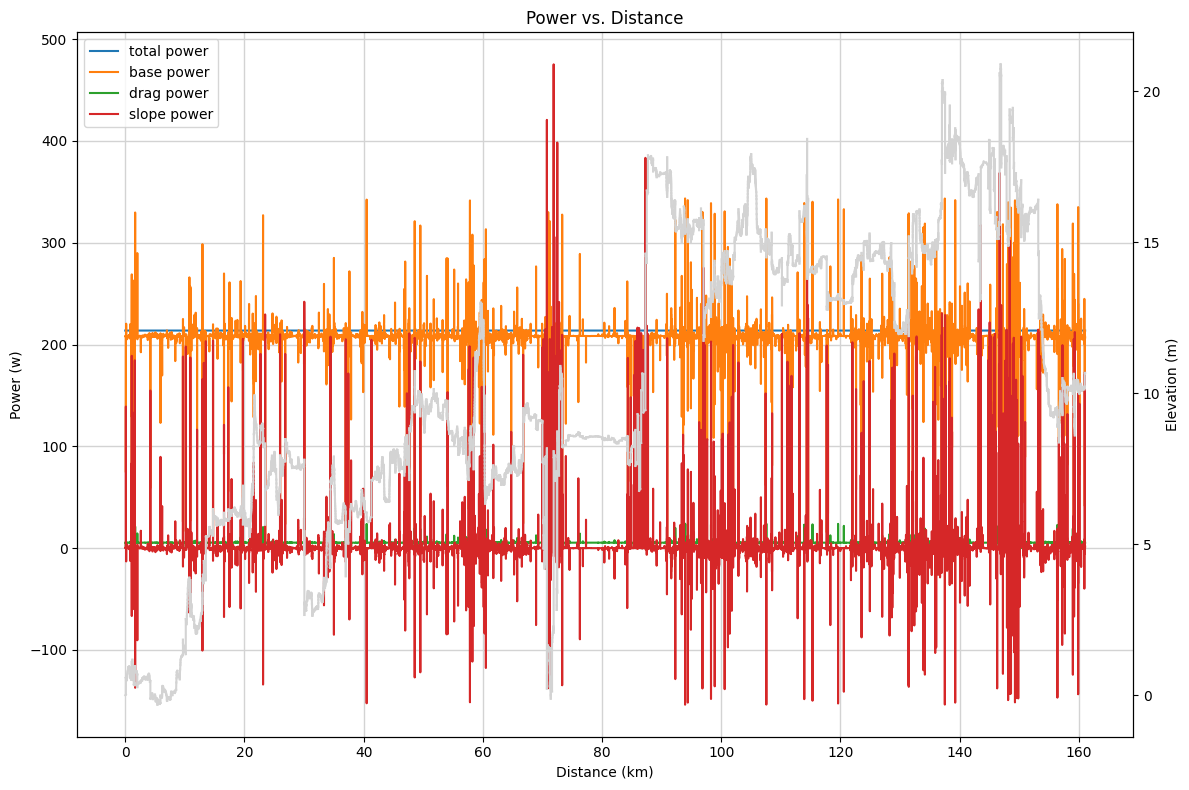

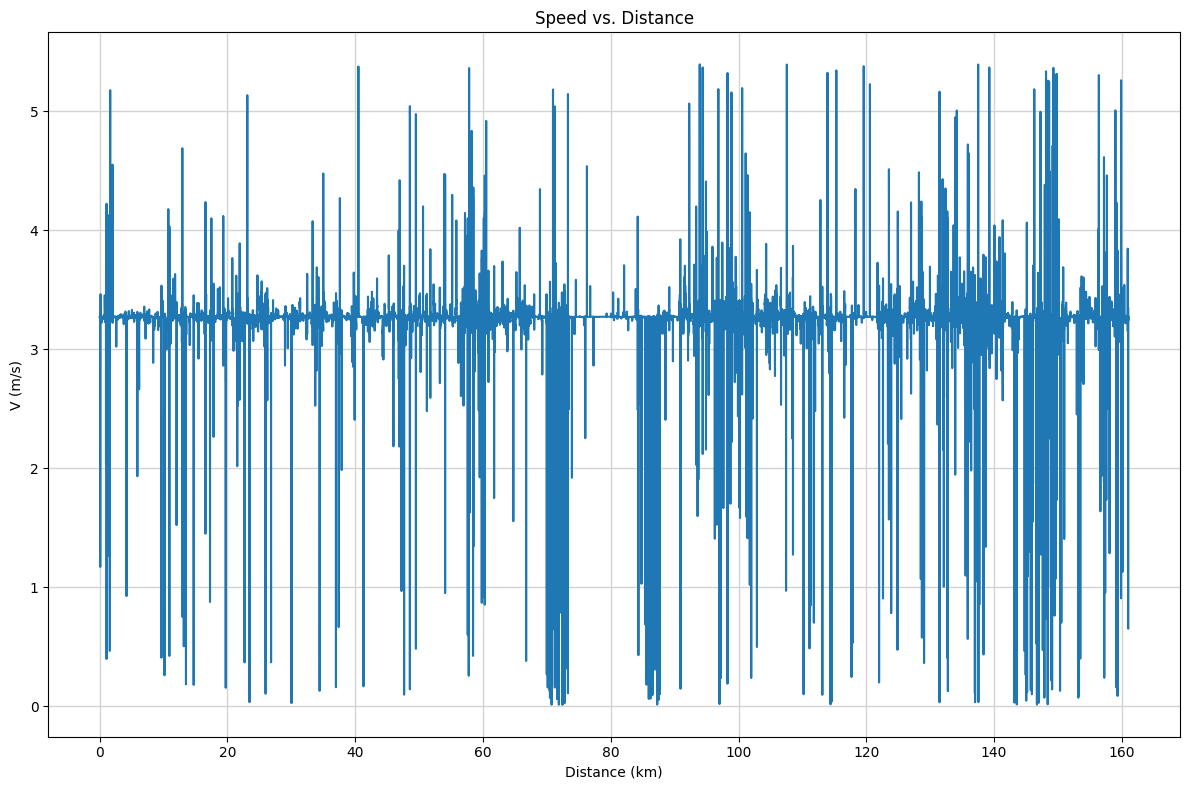

In [16]:
environment = bonk.Environment(temperature = 15, humidity = 0, wind = 0, altitude = 0, body = 1)
athlete = jack

testPerformance = bonk.Performance(environment,athlete,huron100Course)
raceTime, power = testPerformance.getRaceTime()

h, m, s = bonk.getTime(raceTime)
out = 'Race time: {:02d}:{:02d}:{:02d}'
print(out.format(int(h),int(m),int(s)))



testPerformance.plotPowerDistance()
testPerformance.plotVDistance()

testPerformance.getMileSplits(relative = 0)
print('normalized power',testPerformance.getNormalizedPower())